# Customer Segmentation using RFM Analysis

In this notebook, we segment customers using the RFM (Recency, Frequency, Monetary) framework.

The objectives are to:

- Calculate customer-level RFM metrics.
- Identify high-value and at-risk customers.
- Visualize customer segments.
- Generate actionable business insights for marketing and customer retention.

In [2]:
# Import required libraries

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [3]:
# Define project directories

PROJECT_ROOT = Path("..")

RESULTS_DIR = PROJECT_ROOT / "data" / "results"

In [4]:
# Load the analytical dataset created in Notebook 2

df = pd.read_parquet(
    RESULTS_DIR / "customer_analytics.parquet"
)

# Display the shape of the dataset
print(f"Dataset Shape: {df.shape}")

# Preview the data
df.head()

Dataset Shape: (119143, 38)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_score,delivery_days,delivery_vs_estimate_days,order_month,order_year,order_day_of_week,order_hour,order_month_num
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1.0,credit_card,1.0,18.12,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,4.0,8.0,7.0,2017-10,2017,Monday,10,10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3.0,voucher,1.0,2.00,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,4.0,8.0,7.0,2017-10,2017,Monday,10,10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2.0,voucher,1.0,18.59,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,4.0,8.0,7.0,2017-10,2017,Monday,10,10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1.0,boleto,1.0,141.46,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,4.0,13.0,5.0,2018-07,2018,Tuesday,20,7
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1.0,credit_card,3.0,179.12,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,5.0,9.0,17.0,2018-08,2018,Wednesday,8,8


In [5]:
# Create a reference date for calculating recency.
# We use one day after the latest purchase in the dataset.

reference_date = (
    df["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

print(f"Reference Date: {reference_date}")

Reference Date: 2018-10-18 17:30:18


In [6]:
# Calculate Recency, Frequency, and Monetary (RFM) metrics
# for each unique customer.

rfm = (
    df.groupby("customer_unique_id")
    .agg(
        recency=(
            "order_purchase_timestamp",
            lambda x: (reference_date - x.max()).days
        ),
        frequency=(
            "order_id",
            "nunique"
        ),
        monetary=(
            "payment_value",
            "sum"
        )
    )
    .reset_index()
)

rfm.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


In [7]:
# Display the shape and summary statistics of the RFM dataset

print(f"Number of Customers: {rfm.shape[0]}")

rfm.describe().T

Number of Customers: 96096


,count,mean,std,min,25%,50%,75%,max
recency,96096.0,288.735691,153.414676,1.0,164.0,269.00,398.0000,773.00
frequency,96096.0,1.034809,0.214384,1.0,1.0,1.00,1.0000,17.00
monetary,96096.0,214.157343,644.891987,0.0,64.0,113.34,203.4225,109312.64


In [8]:
# Check for missing values in the RFM dataset

rfm.isnull().sum()

customer_unique_id    0
recency               0
frequency             0
monetary              0
dtype: int64

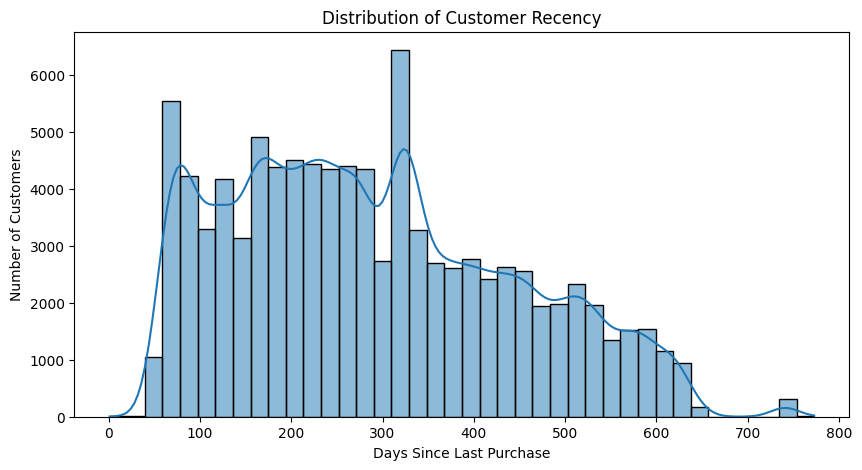

In [9]:
# Distribution of customer recency

plt.figure(figsize=(10, 5))

sns.histplot(
    data=rfm,
    x="recency",
    bins=40,
    kde=True
)

plt.title("Distribution of Customer Recency")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.show()

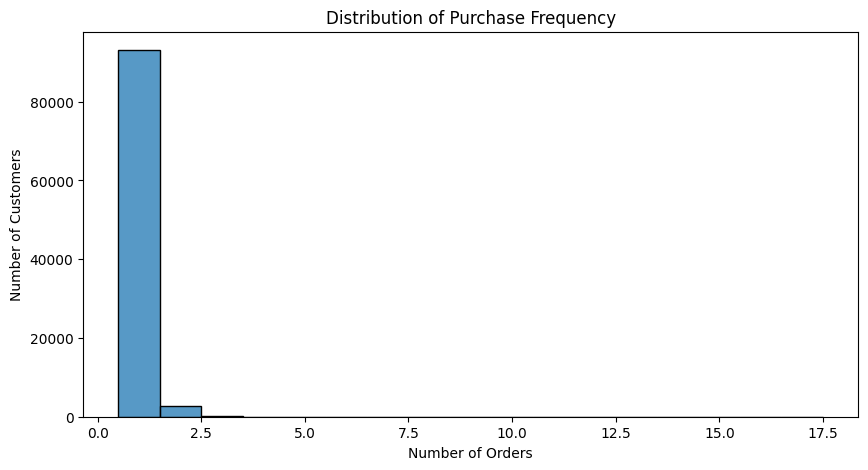

In [10]:
# Distribution of purchase frequency

plt.figure(figsize=(10, 5))

sns.histplot(
    data=rfm,
    x="frequency",
    bins=30,
    discrete=True
)

plt.title("Distribution of Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

The purchase frequency distribution is highly concentrated at a single order, indicating that most customers made only one purchase during the observation period. Only a small proportion of customers returned for multiple purchases, highlighting an opportunity to improve customer retention and repeat buying.

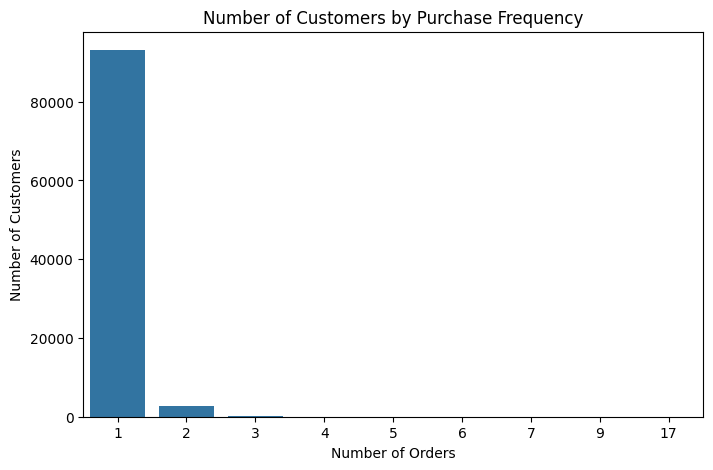

In [13]:
freq_counts = (
    rfm["frequency"]
    .value_counts()
    .sort_index()
    .head(10)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=freq_counts.index,
    y=freq_counts.values
)

plt.title("Number of Customers by Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

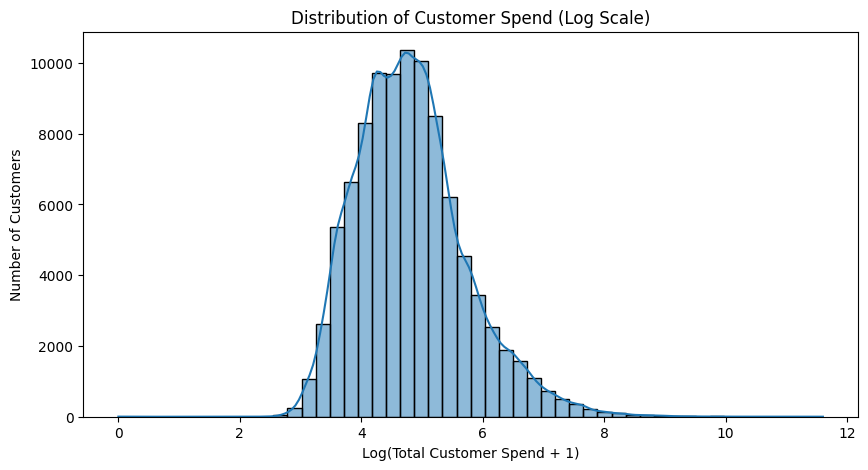

In [12]:
# Distribution of customer monetary value (log scale)

plt.figure(figsize=(10, 5))

sns.histplot(
    np.log1p(rfm["monetary"]),
    bins=50,
    kde=True
)

plt.title("Distribution of Customer Spend (Log Scale)")
plt.xlabel("Log(Total Customer Spend + 1)")
plt.ylabel("Number of Customers")

plt.show()

Most customers make relatively modest purchases, while a small group of high-value customers contributes disproportionately to total spending. The log transformation highlights the spending behavior of the broader customer base by reducing the influence of extreme outliers.

In [15]:
# Calculate cumulative revenue and customer percentages

rfm_sorted = (
    rfm
    .sort_values("monetary", ascending=False)
    .reset_index(drop=True)
)

rfm_sorted["cumulative_revenue"] = (
    rfm_sorted["monetary"].cumsum()
    / rfm_sorted["monetary"].sum()
) * 100

rfm_sorted["customer_percentage"] = (
    np.arange(1, len(rfm_sorted) + 1)
    / len(rfm_sorted)
) * 100

In [17]:
# Find the customer percentage where cumulative revenue reaches 80%

pareto_point = rfm_sorted.loc[
    rfm_sorted["cumulative_revenue"] >= 80,
    "customer_percentage"
].iloc[0]

pareto_point

np.float64(41.71037296037296)

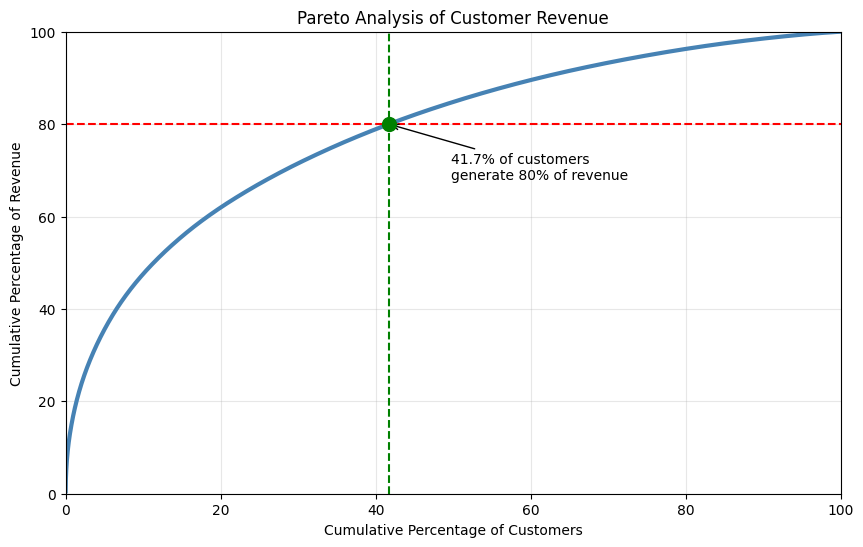

In [18]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(
    rfm_sorted["customer_percentage"],
    rfm_sorted["cumulative_revenue"],
    linewidth=3,
    color="steelblue"
)

# 80% revenue line
ax.axhline(
    80,
    color="red",
    linestyle="--"
)

# Actual customer percentage
ax.axvline(
    pareto_point,
    color="green",
    linestyle="--"
)

# Highlight intersection
ax.scatter(
    pareto_point,
    80,
    color="green",
    s=100,
    zorder=5
)

ax.annotate(
    f"{pareto_point:.1f}% of customers\ngenerate 80% of revenue",
    xy=(pareto_point, 80),
    xytext=(pareto_point + 8, 68),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.title("Pareto Analysis of Customer Revenue")
plt.xlabel("Cumulative Percentage of Customers")
plt.ylabel("Cumulative Percentage of Revenue")

plt.xlim(0,100)
plt.ylim(0,100)

plt.grid(alpha=0.3)

plt.show()

Approximately 40% of customers account for 80% of total revenue, indicating that revenue is concentrated among higher-value customers, but less heavily than the classic 80/20 Pareto distribution. This suggests customer value is more broadly distributed across the customer base than in many retail businesses.

In [20]:
# Create RFM scores using quartiles
# For recency, lower is better, so the most recent customers get a higher score.

rfm["R_score"] = pd.qcut(
    rfm["recency"],
    q=4,
    labels=[4, 3, 2, 1]
)

# For frequency, higher is better.
# rank(method="first") helps avoid issues when many customers have the same frequency.

rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4]
)

# For monetary value, higher is better.

rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    q=4,
    labels=[1, 2, 3, 4]
)

rfm.head()

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,3
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,3


In [21]:
# Combine R, F, and M scores into a single RFM score

rfm["RFM_score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

# Create total RFM score for simpler segmentation

rfm["RFM_total_score"] = (
    rfm["R_score"].astype(int)
    + rfm["F_score"].astype(int)
    + rfm["M_score"].astype(int)
)

rfm.head()

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,RFM_total_score
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,3,413,8
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1,411,6
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2,112,4
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1,211,4
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,3,213,6


In [22]:
# Segment customers based on RFM behavior

def assign_segment(row):
    
    if row["R_score"] >= 3 and row["F_score"] >= 3 and row["M_score"] >= 3:
        return "Champions"
    
    elif row["R_score"] >= 3 and row["F_score"] >= 3:
        return "Loyal Customers"
    
    elif row["R_score"] >= 3 and row["M_score"] >= 3:
        return "Potential Loyalists"
    
    elif row["R_score"] <= 2 and row["F_score"] >= 3 and row["M_score"] >= 3:
        return "At Risk High Value"
    
    elif row["R_score"] <= 2 and row["F_score"] <= 2:
        return "Needs Attention"
    
    else:
        return "Others"


rfm["customer_segment"] = rfm.apply(assign_segment, axis=1)

rfm.head()

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,RFM_total_score,customer_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,3,413,8,Potential Loyalists
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1,411,6,Others
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2,112,4,Needs Attention
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1,211,4,Needs Attention
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,3,213,6,Needs Attention


In [23]:
# Count customers in each segment

segment_counts = (
    rfm["customer_segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["customer_segment", "customer_count"]

segment_counts

,customer_segment,customer_count
0,Needs Attention,24081
1,Others,24065
2,Champions,12561
3,At Risk High Value,12014
4,Potential Loyalists,11828
5,Loyal Customers,11547


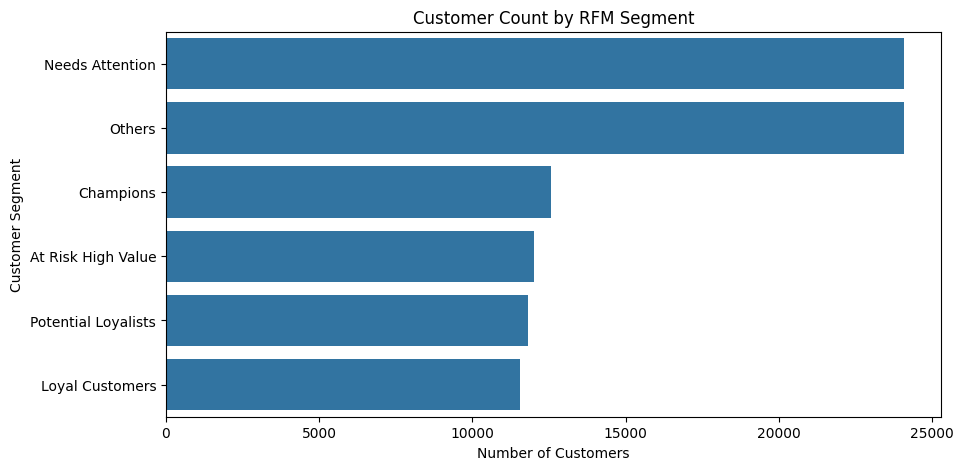

In [24]:
# Visualize number of customers by segment

plt.figure(figsize=(10, 5))

sns.barplot(
    data=segment_counts,
    x="customer_count",
    y="customer_segment"
)

plt.title("Customer Count by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.show()

In [25]:
# Summarize RFM metrics by customer segment

segment_summary = (
    rfm
    .groupby("customer_segment")
    .agg(
        customer_count=("customer_unique_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        total_revenue=("monetary", "sum")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

segment_summary

,customer_segment,customer_count,avg_recency,avg_frequency,avg_monetary,total_revenue
3,Needs Attention,24081,416.237822,1.000000,210.974854,5080485.45
1,Champions,12561,161.988536,1.136374,380.960584,4785245.89
0,At Risk High Value,12014,415.322540,1.105876,361.827745,4346998.53
5,Potential Loyalists,11828,161.462462,1.000000,342.113179,4046514.68
4,Others,24065,287.564970,1.007397,65.196264,1568948.10
2,Loyal Customers,11547,161.814324,1.015762,65.079359,751471.36


In [27]:
rfm.sort_values(
    "monetary",
    ascending=False
).head(10)

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,RFM_total_score,customer_segment
3826,0a0a92112bd4c708ca5fde585afaa872,384,1,109312.64,2,1,4,214,7,Needs Attention
39720,698e1cf81d01a3d389d96145f7fa6df8,421,1,45256.00,1,2,4,124,7,Needs Attention
73664,c402f431464c72e27330a67f7b94d4fb,238,1,44048.00,3,3,4,334,10,Champions
24121,4007669dec559734d6f53e029e360987,328,1,36489.24,2,1,4,214,7,Needs Attention
90000,ef8d54b3797ea4db1d63f0ced6a906e9,182,1,30186.00,3,4,4,344,11,Champions
44447,763c8b1c9c68a0229c42c9fc6f662b93,95,1,29099.52,4,2,4,424,10,Potential Loyalists
75269,c8460e4251689ba205045f3ea17884a1,71,4,27935.46,4,4,4,444,12,Champions
88262,eae0a83d752b1dd32697e0e7b4221656,177,2,25051.89,3,4,4,344,11,Champions
23071,3d47f4368ccc8e1bb4c4a12dbda7111b,381,1,22346.60,2,1,4,214,7,Needs Attention
65407,adfa1cab2b2c8706db21bb13c0a1beb1,138,1,19457.04,4,3,4,434,11,Champions


In [28]:
segment_summary = (
    rfm
    .groupby("customer_segment")
    .agg(
        customer_count=("customer_unique_id", "count"),
        avg_recency=("recency", "mean"),
        median_recency=("recency", "median"),
        avg_frequency=("frequency", "mean"),
        median_frequency=("frequency", "median"),
        avg_monetary=("monetary", "mean"),
        median_monetary=("monetary", "median")
    )
    .round(2)
)

segment_summary

,customer_count,avg_recency,median_recency,avg_frequency,median_frequency,avg_monetary,median_monetary
customer_segment,,,,,,,
At Risk High Value,12014,415.32,395.0,1.11,1.0,361.83,208.62
Champions,12561,161.99,164.0,1.14,1.0,380.96,207.25
Loyal Customers,11547,161.81,165.0,1.02,1.0,65.08,63.50
Needs Attention,24081,416.24,399.0,1.00,1.0,210.97,108.16
Others,24065,287.56,268.0,1.01,1.0,65.20,64.01
Potential Loyalists,11828,161.46,164.0,1.00,1.0,342.11,197.26


## Customer Segment Summary

The RFM analysis segmented customers into six behavioral groups based on their recency, purchase frequency, and total spending. The customer base is relatively balanced across the segments, with **Needs Attention (25.1%)** and **Others (25.0%)** representing the largest groups, while the remaining four segments each account for approximately **12–13%** of customers.

The **Champions** segment represents the most valuable customers. These customers purchased relatively recently (median recency of **164 days**) and have the highest average monetary value (**380.96**), contributing nearly **4.8 million** in revenue. Similarly, **Potential Loyalists** demonstrate strong spending behavior (average monetary value of **342.11**) while maintaining recent purchase activity, making them strong candidates for targeted loyalty campaigns.

The **At Risk High Value** segment is particularly important from a business perspective. Although these customers have spending levels comparable to Champions (average monetary value of **361.83**), they have not made a purchase for more than **395 days** on median. Re-engaging this group represents a valuable opportunity to recover high-value customers before they are permanently lost.

The **Needs Attention** segment contributes the largest share of total revenue (**5.08 million**) because it contains the highest number of customers. However, their long purchase recency (median **399 days**) indicates that many customers have become inactive despite historically generating meaningful revenue. In contrast, the **Others** and **Loyal Customers** segments exhibit substantially lower spending levels, averaging approximately **65** per customer.

An important observation is that the **median purchase frequency equals one across every segment**, indicating that most customers made only a single purchase during the observation period. As a result, customer segmentation in this dataset is driven primarily by **recency** and **monetary value**, while purchase frequency provides limited discriminatory power. This characteristic should be considered when interpreting the RFM segments and designing customer engagement strategies.

### Key Insights

- **Champions** generate the highest average revenue per customer while maintaining relatively recent purchase activity.
- **At Risk High Value** customers exhibit spending behavior similar to Champions but have been inactive for a considerably longer period, making them the highest-priority retention segment.
- Nearly **half of the customer base** falls into either the **Needs Attention** or **Others** segments, suggesting a substantial opportunity for customer reactivation campaigns.
- The dataset contains relatively few repeat purchasers, meaning **customer value is better differentiated by recency and spending than by purchase frequency**.

In [30]:
# Summarize RFM metrics by customer segment

segment_summary = (
    rfm
    .groupby("customer_segment")
    .agg(
        customer_count=("customer_unique_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        total_revenue=("monetary", "sum")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

segment_summary

,customer_segment,customer_count,avg_recency,avg_frequency,avg_monetary,total_revenue
3,Needs Attention,24081,416.237822,1.000000,210.974854,5080485.45
1,Champions,12561,161.988536,1.136374,380.960584,4785245.89
0,At Risk High Value,12014,415.322540,1.105876,361.827745,4346998.53
5,Potential Loyalists,11828,161.462462,1.000000,342.113179,4046514.68
4,Others,24065,287.564970,1.007397,65.196264,1568948.10
2,Loyal Customers,11547,161.814324,1.015762,65.079359,751471.36


In [31]:
# Calculate revenue share by segment

segment_summary["revenue_share"] = (
    segment_summary["total_revenue"] 
    / segment_summary["total_revenue"].sum()
) * 100

segment_summary

,customer_segment,customer_count,avg_recency,avg_frequency,avg_monetary,total_revenue,revenue_share
3,Needs Attention,24081,416.237822,1.000000,210.974854,5080485.45,24.686921
1,Champions,12561,161.988536,1.136374,380.960584,4785245.89,23.252303
0,At Risk High Value,12014,415.322540,1.105876,361.827745,4346998.53,21.122787
5,Potential Loyalists,11828,161.462462,1.000000,342.113179,4046514.68,19.662686
4,Others,24065,287.564970,1.007397,65.196264,1568948.10,7.623779
2,Loyal Customers,11547,161.814324,1.015762,65.079359,751471.36,3.651524


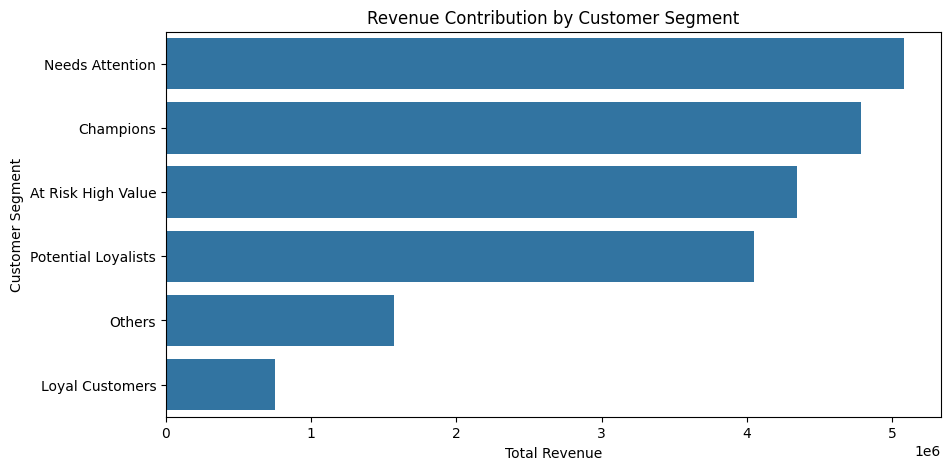

In [32]:
# Visualize revenue contribution by segment

plt.figure(figsize=(10, 5))

sns.barplot(
    data=segment_summary,
    x="total_revenue",
    y="customer_segment"
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Total Revenue")
plt.ylabel("Customer Segment")

plt.show()

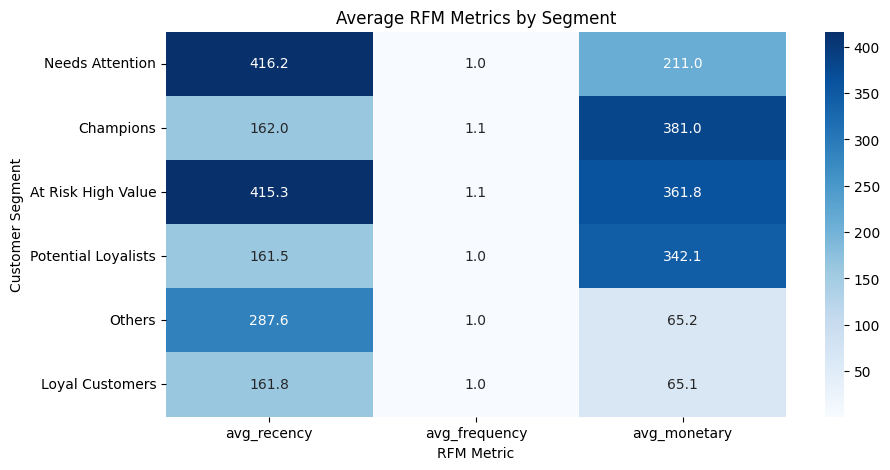

In [33]:
# Heatmap of average RFM metrics by segment

heatmap_data = (
    segment_summary
    .set_index("customer_segment")
    [["avg_recency", "avg_frequency", "avg_monetary"]]
)

plt.figure(figsize=(10, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Average RFM Metrics by Segment")
plt.xlabel("RFM Metric")
plt.ylabel("Customer Segment")

plt.show()

In [34]:
# Save customer-level RFM table

rfm.to_parquet(
    RESULTS_DIR / "customer_rfm.parquet",
    index=False
)

# Save segment summary

segment_summary.to_csv(
    RESULTS_DIR / "rfm_segment_summary.csv",
    index=False
)

## Notebook Summary

In this notebook, we segmented customers using the RFM (Recency, Frequency, Monetary) framework to better understand purchasing behavior and customer value. The analysis identified six distinct customer segments with varying levels of engagement and spending.

The results show that **Champions** and **Potential Loyalists** are the highest-value customer segments, while **At Risk High Value** customers represent an important opportunity for retention campaigns due to their historically high spending but long periods of inactivity. Although the **Needs Attention** segment contributes the highest total revenue because of its size, many customers in this group have not purchased recently, indicating the need for re-engagement strategies.

One notable characteristic of the dataset is that most customers made only a single purchase, limiting the contribution of the Frequency metric. Consequently, customer segmentation is driven primarily by **Recency** and **Monetary Value**. These customer segments provide a strong foundation for targeted marketing campaigns and will be used in subsequent analyses to further explore customer retention and revenue trends.